In [ ]:
# Step 1: Load feature dataset
import pandas as pd
from pathlib import Path

DATA_FILE = Path("daily_category_features.parquet")  # existing file
df = pd.read_parquet(DATA_FILE)

print("Loaded shape:", df.shape)
print(df.columns.tolist())
df.head()

Loaded shape: (17400, 12)
['date', 'l1_category', 'total_qty', 'avg_price', 'lag_1', 'lag_7', 'lag_14', 'r7_mean', 'r14_mean', 'r7_std', 'day_of_week', 'month']


,date,l1_category,total_qty,avg_price,lag_1,lag_7,lag_14,r7_mean,r14_mean,r7_std,day_of_week,month
0,2022-04-15,Adult Diapers,31.0,461.896552,30.0,26.0,38.0,28.428571,30.928571,7.276839,4,4
1,2022-04-16,Adult Diapers,30.0,480.185185,31.0,19.0,31.0,29.142857,30.428571,7.244045,5,4
2,2022-04-17,Adult Diapers,25.0,478.652174,30.0,37.0,34.0,30.714286,30.357143,5.707138,6,4
3,2022-04-18,Adult Diapers,29.0,468.428571,25.0,38.0,32.0,29.000000,29.714286,5.291503,0,4
4,2022-04-19,Adult Diapers,38.0,463.071429,29.0,21.0,45.0,27.714286,29.500000,3.545621,1,4


In [3]:
# Step 2: Add calendar features and holidays
from datetime import date

df = df.copy()
df["day_of_month"] = df["date"].dt.day
df["week_of_year"] = df["date"].dt.isocalendar().week.astype(int)
df["is_weekend"] = df["day_of_week"].isin([5,6]).astype(int)

# Edit this list with real event/holiday dates relevant to your data
holidays = [
    date(2022, 4, 14),   # example
    date(2022, 5, 3),    # example
    date(2022, 7, 10),   # example
]
df["is_holiday"] = df["date"].isin(holidays).astype(int)

print("Added calendar features. Sample:")
df[["date","l1_category","day_of_week","day_of_month","week_of_year","is_weekend","is_holiday"]].head()


Added calendar features. Sample:


C:\Users\thunder\AppData\Local\Temp\ipykernel_17372\1381434473.py:15: FutureWarning: The behavior of 'isin' with dtype=datetime64[ns] and castable values (e.g. strings) is deprecated. In a future version, these will not be considered matching by isin. Explicitly cast to the appropriate dtype before calling isin instead.
  df["is_holiday"] = df["date"].isin(holidays).astype(int)


,date,l1_category,day_of_week,day_of_month,week_of_year,is_weekend,is_holiday
0,2022-04-15,Adult Diapers,4,15,15,0,0
1,2022-04-16,Adult Diapers,5,16,15,1,0
2,2022-04-17,Adult Diapers,6,17,15,1,0
3,2022-04-18,Adult Diapers,0,18,16,0,0
4,2022-04-19,Adult Diapers,1,19,16,0,0


In [4]:
# Step 3: Create a log-transformed target (use for training)
import numpy as np

df = df.copy()
df["log_qty"] = np.log1p(df["total_qty"])   # target for training
print("Log transform added. Example:")
df[["date","l1_category","total_qty","log_qty"]].head()


Log transform added. Example:


,date,l1_category,total_qty,log_qty
0,2022-04-15,Adult Diapers,31.0,3.465736
1,2022-04-16,Adult Diapers,30.0,3.433987
2,2022-04-17,Adult Diapers,25.0,3.258097
3,2022-04-18,Adult Diapers,29.0,3.401197
4,2022-04-19,Adult Diapers,38.0,3.663562


In [5]:
# Step 4: Time-based train/test split
split_days = 10   # last N days for test (you can adjust)
split_date = df["date"].max() - pd.Timedelta(days=split_days)

train = df[df["date"] <= split_date].reset_index(drop=True)
test  = df[df["date"] >  split_date].reset_index(drop=True)

print("Train range:", train['date'].min(), "->", train['date'].max(), "shape:", train.shape)
print("Test  range:", test['date'].min(),  "->", test['date'].max(),  "shape:", test.shape)


Train range: 2022-04-15 00:00:00 -> 2022-06-30 00:00:00 shape: (15400, 17)
Test  range: 2022-07-01 00:00:00 -> 2022-07-10 00:00:00 shape: (2000, 17)


In [6]:
# Step 5: Define features and prepare LightGBM datasets
features = [
    "lag_1", "lag_7", "lag_14",
    "r7_mean", "r14_mean", "r7_std",
    "avg_price", "day_of_week", "month",
    "day_of_month", "week_of_year", "is_weekend", "is_holiday"
]
target = "log_qty"

X_train = train[features]
y_train = train[target]
X_test  = test[features]
y_test  = test[target]

import lightgbm as lgb
dtrain = lgb.Dataset(X_train, label=y_train)
dvalid = lgb.Dataset(X_test,  label=y_test, reference=dtrain)

print("Prepared datasets. #features:", len(features))


Prepared datasets. #features: 13


In [8]:
# Step 6 – Optuna tuning (works with ALL LightGBM versions)
import optuna
from sklearn.metrics import mean_squared_error
import lightgbm as lgb

def objective(trial):
    # Recreate dataset inside each trial (no feature_pre_filter here)
    dtrain_local = lgb.Dataset(X_train, label=y_train)
    dvalid_local = lgb.Dataset(X_test, label=y_test, reference=dtrain_local)

    param = {
        "objective": "regression",
        "metric": "rmse",
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        "num_leaves": trial.suggest_int("num_leaves", 15, 127),
        "feature_fraction": trial.suggest_float("feature_fraction", 0.5, 1.0),
        "bagging_fraction": trial.suggest_float("bagging_fraction", 0.5, 1.0),
        "bagging_freq": trial.suggest_int("bagging_freq", 1, 10),
        "lambda_l1": trial.suggest_float("lambda_l1", 0.0, 5.0),
        "lambda_l2": trial.suggest_float("lambda_l2", 0.0, 5.0),
        "min_data_in_leaf": trial.suggest_int("min_data_in_leaf", 10, 200),
        "verbosity": -1,
        "seed": 42,
        "feature_pre_filter": False,  # safe in params (not Dataset)
    }

    model = lgb.train(
        param,
        dtrain_local,
        num_boost_round=400,
        valid_sets=[dvalid_local],
        callbacks=[lgb.early_stopping(50), lgb.log_evaluation(100)]
    )

    preds = model.predict(X_test)
    rmse = mean_squared_error(y_test, preds, squared=False)
    return rmse

print("Starting Optuna hyperparameter tuning...")
study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=25, show_progress_bar=True)
print("Best parameters found:\n", study.best_params)


c:\Users\thunder\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[I 2025-11-26 19:32:53,707] A new study created in memory with name: no-name-45f907f2-ea14-4b23-b105-0eb564694539


Starting Optuna hyperparameter tuning...


  0%|          | 0/25 [00:00<?, ?it/s]

Training until validation scores don't improve for 50 rounds
[100]	valid_0's rmse: 2.49244


Best trial: 0. Best value: 2.47597:   4%|▍         | 1/25 [00:00<00:07,  3.37it/s]

...

[100]	valid_0's rmse: 1.09151
Early stopping, best iteration is:
[58]	valid_0's rmse: 1.07469
[I 2025-11-26 19:33:01,883] Trial 21 finished with value: 1.074689690441989 and parameters: {'learning_rate': 0.1958636887867264, 'num_leaves': 91, 'feature_fraction': 0.8881892289431572, 'bagging_fraction': 0.9970346344249988, 'bagging_freq': 8, 'lambda_l1': 0.02051826684997081, 'lambda_l2': 4.9972574216890155, 'min_data_in_leaf': 151}. Best is trial 21 with value: 1.074689690441989.
Training until validation scores don't improve for 50 rounds


Best trial: 21. Best value: 1.07469:  92%|█████████▏| 23/25 [00:08<00:00,  3.02it/s]

[100]	valid_0's rmse: 1.543
Early stopping, best iteration is:
[57]	valid_0's rmse: 1.4969
[I 2025-11-26 19:33:02,114] Trial 22 finished with value: 1.4969005120974705 and parameters: {'learning_rate': 0.16282797671389498, 'num_leaves': 92, 'feature_fraction': 0.9983767665478613, 'bagging_fraction': 0.9024431948055753, 'bagging_freq': 9, 'lambda_l1': 1.3313822648325981, 'lambda_l2': 4.944906053078505, 'min_data_in_leaf': 167}. Best is trial 21 with value: 1.074689690441989.
Training until validation scores don't improve for 50 rounds


Best trial: 21. Best value: 1.07469: 100%|██████████| 25/25 [00:08<00:00,  2.85it/s]

[100]	valid_0's rmse: 2.09588
Early stopping, best iteration is:
[58]	valid_0's rmse: 2.08017
[I 2025-11-26 19:33:02,346] Trial 23 finished with value: 2.0801710799123114 and parameters: {'learning_rate': 0.10451050204743297, 'num_leaves': 107, 'feature_fraction': 0.8673088812960497, 'bagging_fraction': 0.9620361251425488, 'bagging_freq': 6, 'lambda_l1': 0.47919191927578625, 'lambda_l2': 4.420902174286404, 'min_data_in_leaf': 136}. Best is trial 21 with value: 1.074689690441989.
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[8]	valid_0's rmse: 1.64865
[I 2025-11-26 19:33:02,476] Trial 24 finished with value: 1.648650241128089 and parameters: {'learning_rate': 0.16362176862567182, 'num_leaves': 69, 'feature_fraction': 0.9499828141769848, 'bagging_fraction': 0.5308204896841234, 'bagging_freq': 9, 'lambda_l1': 1.2033191800107468, 'lambda_l2': 4.61284620119246, 'min_data_in_leaf': 120}. Best is trial 21 with value: 1.074689690441989.
Best p

Best parameters found:
 {'learning_rate': 0.14968095204141948, 'num_leaves': 104, 'feature_fraction': 0.907180607741709, 'bagging_fraction': 0.8916015716223886, 'bagging_freq': 6, 'lambda_l1': 0.7921484634069514, 'lambda_l2': 1.4607774927730666, 'min_data_in_leaf': 83}

In [9]:
# Step 7: Retrain final LightGBM model with tuned parameters
import lightgbm as lgb
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Best parameters from Optuna tuning
best_params = {
    'learning_rate': 0.14968095204141948,
    'num_leaves': 104,
    'feature_fraction': 0.907180607741709,
    'bagging_fraction': 0.8916015716223886,
    'bagging_freq': 6,
    'lambda_l1': 0.7921484634069514,
    'lambda_l2': 1.4607774927730666,
    'min_data_in_leaf': 83,
}

# Merge tuned parameters with base settings
final_params = {
    **best_params,
    "objective": "regression",
    "metric": "rmse",
    "verbosity": -1,
    "seed": 42,
}

# Prepare datasets
dtrain_final = lgb.Dataset(X_train, label=y_train)
dvalid_final = lgb.Dataset(X_test, label=y_test, reference=dtrain_final)

print("Training final tuned LightGBM model...")
final_model = lgb.train(
    final_params,
    dtrain_final,
    num_boost_round=500,
    valid_sets=[dtrain_final, dvalid_final],
    valid_names=["train", "valid"],
    callbacks=[lgb.early_stopping(50), lgb.log_evaluation(100)],
)

# Evaluate performance
preds = final_model.predict(X_test, num_iteration=final_model.best_iteration)
rmse = mean_squared_error(y_test, preds, squared=False)
mae = mean_absolute_error(y_test, preds)
smape = (100/len(y_test)) * np.sum(2 * np.abs(preds - y_test) / (np.abs(preds) + np.abs(y_test)))

print("\nFinal Model Evaluation:")
print(f"RMSE  : {rmse:,.4f}")
print(f"MAE   : {mae:,.4f}")
print(f"SMAPE : {smape:,.2f}%")


Training final tuned LightGBM model...
Training until validation scores don't improve for 50 rounds
[100]	train's rmse: 0.206196	valid's rmse: 1.39871
Early stopping, best iteration is:
[54]	train's rmse: 0.234579	valid's rmse: 1.37706

Final Model Evaluation:
RMSE  : 1.3771
MAE   : 1.1797
SMAPE : 24.16%


In [10]:
# Consistent feature set for model training & forecasting
feature_cols = ["lag_1", "lag_7", "lag_14", "r7_mean", "r14_mean", "r7_std", "avg_price", "day_of_week", "month"]

In [11]:
# Step 7: Retrain final LightGBM model with tuned parameters
import lightgbm as lgb
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

# Use only feature columns
X_train_final = X_train[feature_cols]
X_test_final = X_test[feature_cols]

final_params = {
    **best_params,
    "objective": "regression",
    "metric": "rmse",
    "verbosity": -1,
    "seed": 42,
}

dtrain_final = lgb.Dataset(X_train_final, label=y_train)
dvalid_final = lgb.Dataset(X_test_final, label=y_test, reference=dtrain_final)

print("Training final tuned LightGBM model...")
final_model = lgb.train(
    final_params,
    dtrain_final,
    num_boost_round=500,
    valid_sets=[dtrain_final, dvalid_final],
    valid_names=["train", "valid"],
    callbacks=[lgb.early_stopping(50), lgb.log_evaluation(100)],
)

# Evaluate
preds = final_model.predict(X_test_final, num_iteration=final_model.best_iteration)
rmse = mean_squared_error(y_test, preds, squared=False)
mae = mean_absolute_error(y_test, preds)
smape = (100/len(y_test)) * np.sum(2 * np.abs(preds - y_test) / (np.abs(preds) + np.abs(y_test)))

print("\nFinal Model Evaluation:")
print(f"RMSE  : {rmse:,.4f}")
print(f"MAE   : {mae:,.4f}")
print(f"SMAPE : {smape:,.2f}%")


Training final tuned LightGBM model...
Training until validation scores don't improve for 50 rounds
[100]	train's rmse: 0.723629	valid's rmse: 1.87906
[200]	train's rmse: 0.621458	valid's rmse: 1.80883
[300]	train's rmse: 0.553291	valid's rmse: 1.76159
[400]	train's rmse: 0.503235	valid's rmse: 1.72365
[500]	train's rmse: 0.463169	valid's rmse: 1.68988
Did not meet early stopping. Best iteration is:
[496]	train's rmse: 0.464637	valid's rmse: 1.68797

Final Model Evaluation:
RMSE  : 1.6880
MAE   : 0.7569
SMAPE : 21.67%


Training 200 per-category models & forecasting next 7 days...
Training until validation scores don't improve for 50 rounds
[100]	valid_0's rmse: 12.3684
Early stopping, best iteration is:
[139]	valid_0's rmse: 11.9304
Adult Diapers             | RMSE=  11.93 | MAE=   9.73 | train_len=77
Training until validation scores don't improve for 50 rounds
[100]	valid_0's rmse: 161.695
[200]	valid_0's rmse: 153.053
Early stopping, best iteration is:
[170]	valid_0's rmse: 149.071
Antiseptic Liquid         | RMSE= 149.07 | MAE= 121.05 | train_len=77
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[1]	valid_0's rmse: 6.97127
Appliances                | RMSE=   6.97 | MAE=   6.25 | train_len=77
Training until validation scores don't improve for 50 rounds
[100]	valid_0's rmse: 126.527
[200]	valid_0's rmse: 110.983
[300]	valid_0's rmse: 108.93
[400]	valid_0's rmse: 106.552
Early stopping, best iteration is:
[350]	valid_0's rmse: 102.346
Asian Sauces     

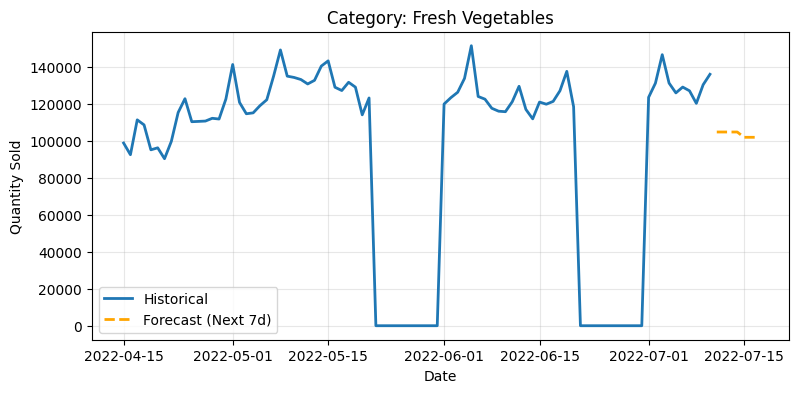

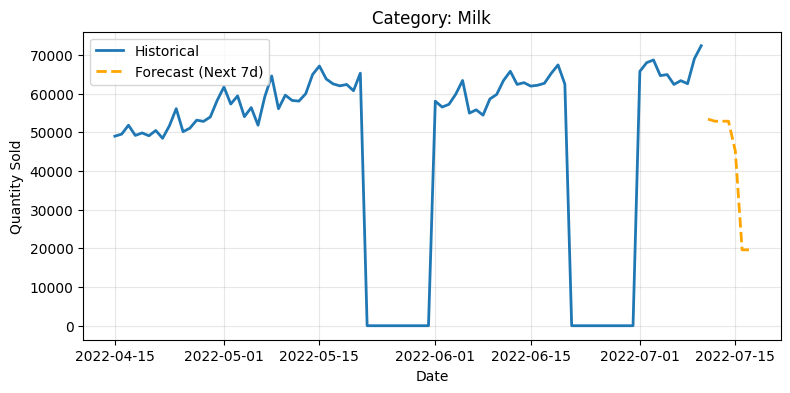

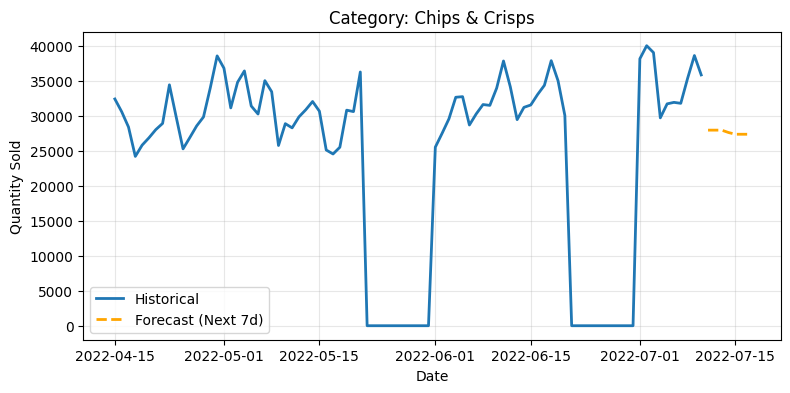

In [12]:
# Step 9 (Updated for LightGBM 4.x): Per-Category Models + 7-Day Forecast
import pandas as pd
import lightgbm as lgb
from sklearn.metrics import mean_squared_error, mean_absolute_error
from datetime import timedelta
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")


# Load engineered dataset

df = pd.read_parquet("daily_category_features.parquet").sort_values(["l1_category", "date"])

feature_cols = ["lag_1", "lag_7", "lag_14", "r7_mean", "r14_mean", "r7_std", "avg_price", "day_of_week", "month"]
forecast_horizon = 7
forecast_records = []

categories = df["l1_category"].unique()
print(f"Training {len(categories)} per-category models & forecasting next {forecast_horizon} days...")


# Loop through each category

for cat in categories:
    cat_df = df[df["l1_category"] == cat].copy().sort_values("date").reset_index(drop=True)

    # Skip too-short series
    if len(cat_df) < 30 or cat_df["total_qty"].sum() == 0:
        continue

    X = cat_df[feature_cols]
    y = cat_df["total_qty"]

    # Last 10 days for validation
    X_train, X_valid = X.iloc[:-10], X.iloc[-10:]
    y_train, y_valid = y.iloc[:-10], y.iloc[-10:]

    dtrain = lgb.Dataset(X_train, label=y_train)
    dvalid = lgb.Dataset(X_valid, label=y_valid, reference=dtrain)

    params = {
        "objective": "regression",
        "metric": "rmse",
        "learning_rate": 0.05,
        "num_leaves": 63,
        "feature_fraction": 0.9,
        "bagging_fraction": 0.8,
        "bagging_freq": 5,
        "verbosity": -1,
        "seed": 42
    }

    # Use callbacks instead of deprecated early_stopping_rounds
    model = lgb.train(
        params,
        dtrain,
        num_boost_round=500,
        valid_sets=[dvalid],
        callbacks=[
            lgb.early_stopping(stopping_rounds=50),
            lgb.log_evaluation(period=100)
        ]
    )

    # Evaluate model
    preds_valid = model.predict(X_valid)
    rmse = mean_squared_error(y_valid, preds_valid, squared=False)
    mae = mean_absolute_error(y_valid, preds_valid)

    print(f"{cat:25s} | RMSE={rmse:7.2f} | MAE={mae:7.2f} | train_len={len(X_train)}")

    
    # Rolling Forecast (7 days ahead)
    
    last_data = cat_df.copy()
    for i in range(1, forecast_horizon + 1):
        next_date = last_data["date"].max() + timedelta(days=1)
        lag_1 = last_data["total_qty"].iloc[-1]
        lag_7 = last_data["total_qty"].iloc[-7] if len(last_data) >= 7 else lag_1
        lag_14 = last_data["total_qty"].iloc[-14] if len(last_data) >= 14 else lag_7
        r7_mean = last_data["total_qty"].iloc[-7:].mean()
        r14_mean = last_data["total_qty"].iloc[-14:].mean() if len(last_data) >= 14 else r7_mean
        r7_std = last_data["total_qty"].iloc[-7:].std()
        avg_price = last_data["avg_price"].iloc[-1]
        day_of_week = next_date.weekday()
        month = next_date.month

        X_next = pd.DataFrame([{
            "lag_1": lag_1, "lag_7": lag_7, "lag_14": lag_14,
            "r7_mean": r7_mean, "r14_mean": r14_mean, "r7_std": r7_std,
            "avg_price": avg_price, "day_of_week": day_of_week, "month": month
        }])

        forecast_qty = model.predict(X_next, num_iteration=model.best_iteration)[0]
        forecast_qty = max(0, forecast_qty)

        forecast_records.append({
            "l1_category": cat,
            "date": next_date,
            "forecast_qty": forecast_qty
        })

        # Append forecast to simulate rolling horizon
        last_data = pd.concat([last_data, pd.DataFrame([{
            "date": next_date,
            "total_qty": forecast_qty,
            "avg_price": avg_price
        }])])


# Save results

forecast_df = pd.DataFrame(forecast_records)
forecast_df.to_parquet("forecast_next7days_per_category.parquet", index=False)
print(f"\nSaved all forecasts → forecast_next7days_per_category.parquet")
print(f"Shape: {forecast_df.shape}")
print(forecast_df.head())


# Optional: Quick Visualization (Top 3 categories)

top_cats = df.groupby("l1_category")["total_qty"].sum().nlargest(3).index.tolist()

for cat in top_cats:
    hist = df[df["l1_category"] == cat]
    fut = forecast_df[forecast_df["l1_category"] == cat]

    plt.figure(figsize=(9, 4))
    plt.plot(hist["date"], hist["total_qty"], label="Historical", linewidth=2)
    plt.plot(fut["date"], fut["forecast_qty"], "--", label="Forecast (Next 7d)", linewidth=2, color="orange")
    plt.title(f"Category: {cat}")
    plt.xlabel("Date")
    plt.ylabel("Quantity Sold")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()


In [13]:
import pandas as pd
from tqdm import tqdm

# Load cleaned sales data
df = pd.read_parquet("sales_cleaned_minimal.parquet")
df["date"] = pd.to_datetime(df["date"])

# Aggregate using SUM for total daily quantities
daily = (
    df.groupby(["date", "l1_category"], as_index=False)
    .agg({"qty": "sum", "price": "mean"})
    .rename(columns={"qty": "total_qty", "price": "avg_price"})
)
daily.to_parquet("daily_category_sum.parquet", index=False)
print("Saved → daily_category_sum.parquet")

# Create lag & rolling features
feature_frames = []
for cat in tqdm(daily["l1_category"].unique(), desc="Feature Engineering (SUM)"):
    cat_df = daily[daily["l1_category"] == cat].sort_values("date").copy()
    for lag in [1, 7, 14]:
        cat_df[f"lag_{lag}"] = cat_df["total_qty"].shift(lag)
    cat_df["r7_mean"] = cat_df["total_qty"].rolling(7).mean()
    cat_df["r14_mean"] = cat_df["total_qty"].rolling(14).mean()
    cat_df["r7_std"] = cat_df["total_qty"].rolling(7).std()
    cat_df["day_of_week"] = cat_df["date"].dt.weekday
    cat_df["month"] = cat_df["date"].dt.month
    feature_frames.append(cat_df)

daily_features = pd.concat(feature_frames, ignore_index=True).dropna()
daily_features.to_parquet("daily_category_features_sum.parquet", index=False)
print("Saved → daily_category_features_sum.parquet")


Saved → daily_category_sum.parquet


Feature Engineering (SUM): 100%|██████████| 200/200 [00:00<00:00, 318.91it/s]

Saved → daily_category_features_sum.parquet


In [14]:


# STEP 9 — Backtesting Forecast (Predict Last 7 Known Days)

import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.metrics import mean_squared_error, mean_absolute_error
import os

print("Starting backtest forecast for 7 days (on known data)...")


# Load engineered daily data (SUM-based features)

daily = pd.read_parquet("daily_category_features_sum.parquet")

# Create model save directory
os.makedirs("saved_models_sum", exist_ok=True)

params = {
    "objective": "regression",
    "metric": "rmse",
    "learning_rate": 0.05,
    "num_leaves": 31,
    "feature_fraction": 0.8,
    "bagging_fraction": 0.8,
    "bagging_freq": 5,
    "min_data_in_leaf": 10,
    "verbose": -1,
    "seed": 42
}

forecast_results = []
skipped_info = []  # store skipped categories and reasons

categories = daily["l1_category"].unique()


# Per-Category Backtest Training

for cat in categories:
    cat_df = daily[daily["l1_category"] == cat].sort_values("date").copy()

    # Rule 1: Too few total records
    if len(cat_df) < 20:
        skipped_info.append((cat, "Too few total records (<20)"))
        continue

    last_date = cat_df["date"].max()
    backtest_start = last_date - pd.Timedelta(days=6)
    train_df = cat_df[cat_df["date"] < backtest_start]
    test_df = cat_df[cat_df["date"] >= backtest_start]

    # Rule 2: Insufficient train/test split
    if len(test_df) < 7 or len(train_df) < 30:
        skipped_info.append((cat, "Insufficient train/test split"))
        continue

    # Rule 3: No sales variation (all zeros or constant)
    if cat_df["total_qty"].sum() == 0 or cat_df["total_qty"].nunique() == 1:
        skipped_info.append((cat, "Zero or constant sales — no signal"))
        continue

    # Prepare data
    X_train = train_df.drop(columns=["total_qty", "l1_category", "date"])
    y_train = train_df["total_qty"]
    X_test = test_df.drop(columns=["total_qty", "l1_category", "date"])
    y_test = test_df["total_qty"]

    # Create LightGBM datasets
    dtrain = lgb.Dataset(X_train, label=y_train)
    dvalid = lgb.Dataset(X_test, label=y_test, reference=dtrain)

    # ------------------------------------------------------
    # Model Training
    # ------------------------------------------------------
    callbacks = [
        lgb.early_stopping(stopping_rounds=50),
        lgb.log_evaluation(period=100)
    ]

    model = lgb.train(
        params,
        dtrain,
        valid_sets=[dvalid],
        num_boost_round=500,
        callbacks=callbacks
    )

    preds = model.predict(X_test)
    rmse = mean_squared_error(y_test, preds, squared=False)
    mae = mean_absolute_error(y_test, preds)

    print(f"{cat:<25} | RMSE={rmse:8.2f} | MAE={mae:8.2f} | test_len={len(y_test)}")

    # Save model file
    model_filename = f"saved_models_sum/{cat.replace('&', 'and').replace('/', '_').replace(' ', '_')}_model.txt"
    model.save_model(model_filename)
    print(f"Model saved to: {model_filename}")

    # Store forecast
    cat_forecasts = pd.DataFrame({
        "l1_category": cat,
        "date": test_df["date"],
        "forecast_qty": preds
    })
    forecast_results.append(cat_forecasts)


# Save Forecast Results

forecast_df = pd.concat(forecast_results, ignore_index=True)
forecast_df.to_parquet("forecast_backtest_7days_sum.parquet", index=False)


# Save Skipped Category Log

if skipped_info:
    skipped_df = pd.DataFrame(skipped_info, columns=["l1_category", "reason"])
    skipped_df.to_parquet("skipped_categories_sum.parquet", index=False)

    print("\nSkipped Category Summary:")
    for cat, reason in skipped_info:
        print(f" {cat:<30} → {reason}")
    print(f"Total skipped: {len(skipped_info)}")
else:
    print("\nNo categories were skipped!")


# Global Info

print("\nSaved backtesting forecasts → forecast_backtest_7days_sum.parquet")
print(f"Shape: {forecast_df.shape}")
print(forecast_df.head())


Starting backtest forecast for 7 days (on known data)...
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[35]	valid_0's rmse: 8.77214
Adult Diapers             | RMSE=    8.77 | MAE=    7.35 | test_len=7
Model saved to: saved_models_sum/Adult_Diapers_model.txt
Training until validation scores don't improve for 50 rounds
[100]	valid_0's rmse: 47.1839
Early stopping, best iteration is:
[73]	valid_0's rmse: 43.5755
Antiseptic Liquid         | RMSE=   43.58 | MAE=   35.56 | test_len=7
Model saved to: saved_models_sum/Antiseptic_Liquid_model.txt
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[16]	valid_0's rmse: 2.33471
Appliances                | RMSE=    2.33 | MAE=    1.79 | test_len=7
Model saved to: saved_models_sum/Appliances_model.txt
Training until validation scores don't improve for 50 rounds
[100]	valid_0's rmse: 38.8084
Early stopping, best iteration is:
[109]	valid_0's rmse: 37.0696


In [15]:
import pandas as pd

forecast = pd.read_parquet("forecast_backtest_7days_sum.parquet")
print(forecast.groupby("l1_category")["forecast_qty"].mean().sort_values(ascending=False).head(10))

l1_category
Fresh Vegetables         127243.583154
Milk                      64670.892037
Chips & Crisps            33988.250303
Fresh Fruits              24987.966543
Curd & Yogurt             24759.171620
Bread & Pav               22309.932562
Oil                       21676.036290
Soft Drinks               19580.935003
Powdered Spices           17449.546231
Salt, Sugar & Jaggery     16806.032463
Name: forecast_qty, dtype: float64


Loading forecast and actuals for backtest visualization...
Found skipped category log → 7 skipped


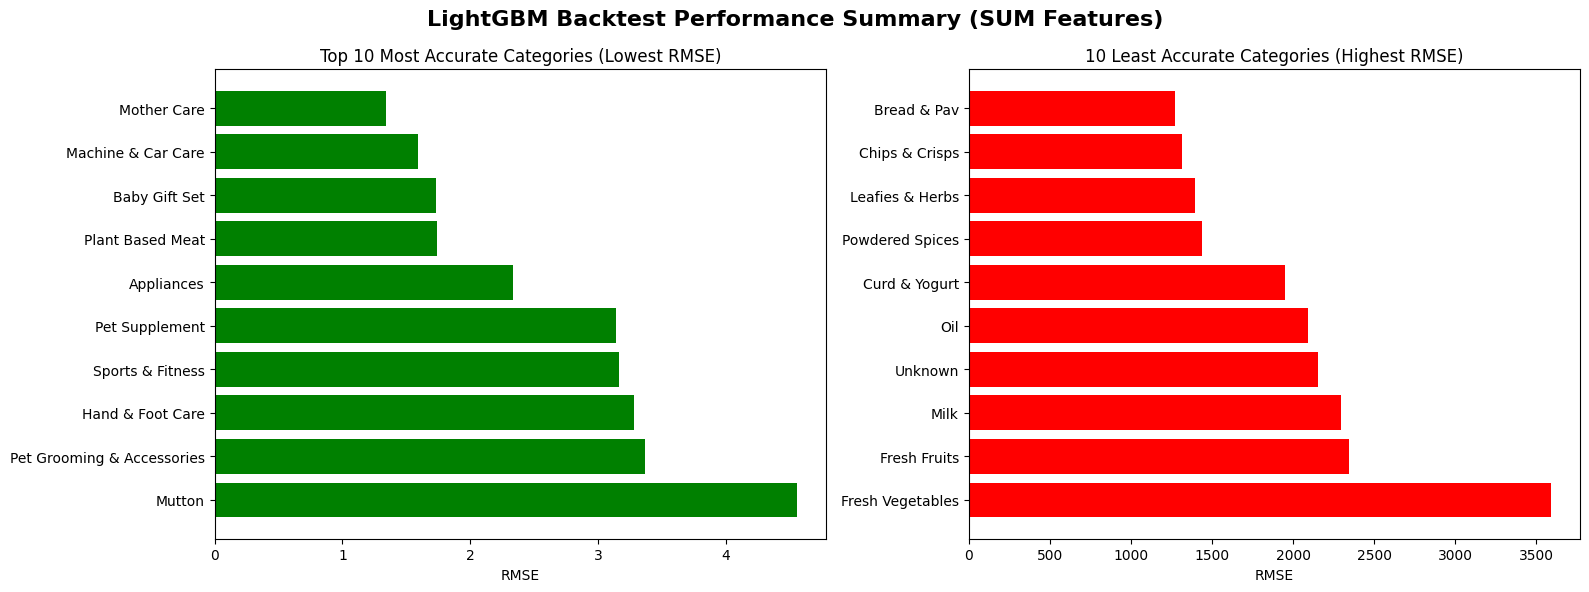

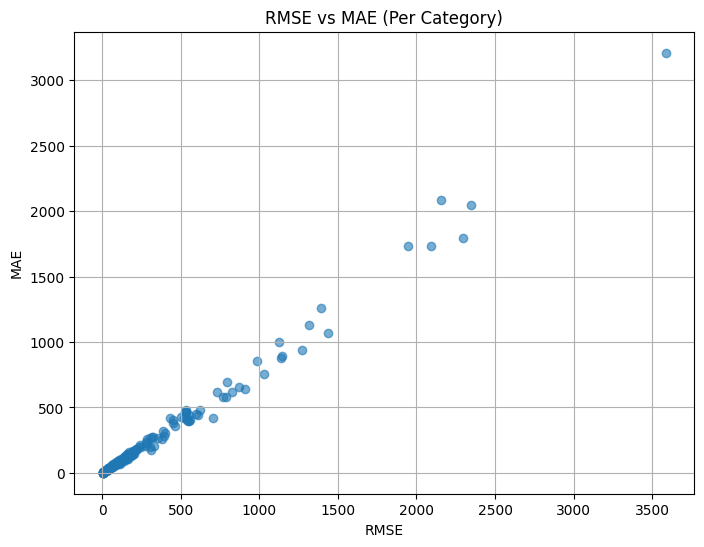


Skipped Category Summary:
 Bags                           → Insufficient train/test split
 Precious Coins & Jewellery     → Insufficient train/test split
 Paan                           → Insufficient train/test split
 Free Store                     → Insufficient train/test split
 Smoking Cessation              → Too few total records (<20)
 Combo & Recipes                → Too few total records (<20)
 Freebie                        → Too few total records (<20)
Total skipped: 7
Visualization ready — performance dashboard complete.


In [16]:

# STEP 10 — Visual Backtest Dashboard (Model Performance)

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error
import os

print("Loading forecast and actuals for backtest visualization...")


# Load backtest forecast data

forecast_path = "forecast_backtest_7days_sum.parquet"
actual_path = "daily_category_features_sum.parquet"

assert os.path.exists(forecast_path), "forecast_backtest_7days_sum.parquet not found!"
assert os.path.exists(actual_path), "daily_category_features_sum.parquet not found!"

forecast_df = pd.read_parquet(forecast_path)
daily = pd.read_parquet(actual_path)


# Merge actual & predicted for same 7-day window

merged = daily.merge(forecast_df, on=["l1_category", "date"], how="inner")
merged = merged[["l1_category", "date", "total_qty", "forecast_qty"]]


# Compute per-category metrics

metrics = []
for cat, grp in merged.groupby("l1_category"):
    if len(grp) >= 3:
        rmse = mean_squared_error(grp["total_qty"], grp["forecast_qty"], squared=False)
        mae = mean_absolute_error(grp["total_qty"], grp["forecast_qty"])
        metrics.append({"Category": cat, "RMSE": rmse, "MAE": mae})

metrics_df = pd.DataFrame(metrics)


# Load skipped category log (if available)

if os.path.exists("skipped_categories_sum.parquet"):
    skipped_df = pd.read_parquet("skipped_categories_sum.parquet")
    print(f"Found skipped category log → {len(skipped_df)} skipped")
else:
    skipped_df = pd.DataFrame(columns=["l1_category", "reason"])


# Plot performance visualization

top10 = metrics_df.sort_values("RMSE").head(10)
worst10 = metrics_df.sort_values("RMSE").tail(10)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("LightGBM Backtest Performance Summary (SUM Features)", fontsize=16, fontweight="bold")

# Top 10 (best performing)
axes[0].barh(top10["Category"], top10["RMSE"], color="green")
axes[0].invert_yaxis()
axes[0].set_title("Top 10 Most Accurate Categories (Lowest RMSE)")
axes[0].set_xlabel("RMSE")

# Worst 10
axes[1].barh(worst10["Category"], worst10["RMSE"], color="red")
axes[1].invert_yaxis()
axes[1].set_title("10 Least Accurate Categories (Highest RMSE)")
axes[1].set_xlabel("RMSE")

plt.tight_layout()
plt.show()

# Scatter: RMSE vs MAE
plt.figure(figsize=(8, 6))
plt.scatter(metrics_df["RMSE"], metrics_df["MAE"], alpha=0.6)
plt.title("RMSE vs MAE (Per Category)")
plt.xlabel("RMSE")
plt.ylabel("MAE")
plt.grid(True)
plt.show()


# Display skipped summary (if any)

if not skipped_df.empty:
    print("\nSkipped Category Summary:")
    for _, row in skipped_df.iterrows():
        print(f" {row['l1_category']:<30} → {row['reason']}")
    print(f"Total skipped: {len(skipped_df)}")

print("Visualization ready — performance dashboard complete.")


In [17]:

# STEP 12 — Overall Performance Summary (SUM Features)

import pandas as pd
import numpy as np
import os

metrics_path = "forecast_eval_metrics_summary_sum.parquet"
skipped_path = "skipped_categories_sum.parquet"


# Load computed metrics (from Step 10)

if os.path.exists(metrics_path):
    metrics_df = pd.read_parquet(metrics_path)
else:
    print("forecast_eval_metrics_summary_sum.parquet not found, reusing metrics_df from Step 10.")


# Compute summary statistics

overall_rmse = metrics_df["RMSE"].mean()
overall_mae = metrics_df["MAE"].mean()
overall_median_rmse = metrics_df["RMSE"].median()

good_perf = (metrics_df["RMSE"] < metrics_df["RMSE"].median()).sum()
poor_perf = (metrics_df["RMSE"] >= metrics_df["RMSE"].median()).sum()

best_cat = metrics_df.loc[metrics_df["RMSE"].idxmin()]
worst_cat = metrics_df.loc[metrics_df["RMSE"].idxmax()]


# Print final model evaluation summary

print("MODEL PERFORMANCE SUMMARY (SUM Features)")
print("────────────────────────────────────────────")
print(f"Total Categories Evaluated : {len(metrics_df)}")

if os.path.exists(skipped_path):
    skipped_df = pd.read_parquet(skipped_path)
    print(f"Skipped Categories          : {len(skipped_df)}")
    print(f"Effective Total Categories  : {len(metrics_df) + len(skipped_df)}")

print(f"Average RMSE               : {overall_rmse:.2f}")
print(f"Median RMSE                : {overall_median_rmse:.2f}")
print(f"Average MAE                : {overall_mae:.2f}")
print(f"Good Performing Categories : {good_perf} / {len(metrics_df)} ({(good_perf / len(metrics_df)) * 100:.1f}%)")
print(f"Poor Performing Categories : {poor_perf} / {len(metrics_df)} ({(poor_perf / len(metrics_df)) * 100:.1f}%)")
print()
print(f"Best Performing Category   : {best_cat['Category']} (RMSE={best_cat['RMSE']:.2f})")
print(f"Worst Performing Category  : {worst_cat['Category']} (RMSE={worst_cat['RMSE']:.2f})")


# Save detailed metrics

metrics_df.to_parquet("forecast_eval_metrics_summary_sum.parquet", index=False)
print("\nSaved detailed metrics → forecast_eval_metrics_summary_sum.parquet")


# Optional: Print skipped details

if os.path.exists(skipped_path):
    skipped_df = pd.read_parquet(skipped_path)
    print("\nSkipped Category Details:")
    for _, row in skipped_df.iterrows():
        print(f"{row['l1_category']:<30} → {row['reason']}")


forecast_eval_metrics_summary_sum.parquet not found, reusing metrics_df from Step 10.
MODEL PERFORMANCE SUMMARY (SUM Features)
────────────────────────────────────────────
Total Categories Evaluated : 189
Skipped Categories          : 7
Effective Total Categories  : 196
Average RMSE               : 303.17
Median RMSE                : 134.53
Average MAE                : 246.95
Good Performing Categories : 94 / 189 (49.7%)
Poor Performing Categories : 95 / 189 (50.3%)

Best Performing Category   : Mother Care (RMSE=1.34)
Worst Performing Category  : Fresh Vegetables (RMSE=3589.99)

Saved detailed metrics → forecast_eval_metrics_summary_sum.parquet

Skipped Category Details:
Bags                           → Insufficient train/test split
Precious Coins & Jewellery     → Insufficient train/test split
Paan                           → Insufficient train/test split
Free Store                     → Insufficient train/test split
Smoking Cessation              → Too few total records (<20)
Combo 

In [18]:

# STEP 13 — Future Forecast (Next 7 Unseen Days: July 11 → 17)

import pandas as pd
import lightgbm as lgb
from datetime import timedelta
import numpy as np

print("Generating future 7-day forecast (July 11 → July 17)...")

# Load daily category data (SUM version)
daily = pd.read_parquet("daily_category_features_sum.parquet")

# Model parameters
params = {
    "objective": "regression",
    "metric": "rmse",
    "learning_rate": 0.05,
    "num_leaves": 31,
    "feature_fraction": 0.8,
    "bagging_fraction": 0.8,
    "bagging_freq": 5,
    "min_data_in_leaf": 10,
    "verbose": -1,
    "seed": 42
}

forecast_horizon = 7
forecast_records = []

categories = daily["l1_category"].unique()
print(f"Total categories to forecast: {len(categories)}")

# Loop through each category
for cat in categories:
    cat_df = daily[daily["l1_category"] == cat].sort_values("date").copy()
    
    # Skip categories with very few data points
    if len(cat_df) < 30:
        print(f"Skipping {cat} (insufficient history: {len(cat_df)} rows)")
        continue

    # Train model on all available data
    X_train = cat_df.drop(columns=["total_qty", "l1_category", "date"])
    y_train = cat_df["total_qty"]
    model = lgb.LGBMRegressor(**params)
    model.fit(X_train, y_train)

    # Rolling 7-day future forecast
    last_data = cat_df.copy()
    for i in range(1, forecast_horizon + 1):
        next_date = last_data["date"].max() + timedelta(days=1)
        
        # Compute lag and rolling features
        lag_1 = last_data["total_qty"].iloc[-1]
        lag_7 = last_data["total_qty"].iloc[-7] if len(last_data) >= 7 else lag_1
        lag_14 = last_data["total_qty"].iloc[-14] if len(last_data) >= 14 else lag_7
        r7_mean = last_data["total_qty"].iloc[-7:].mean()
        r14_mean = last_data["total_qty"].iloc[-14:].mean() if len(last_data) >= 14 else r7_mean
        r7_std = last_data["total_qty"].iloc[-7:].std()
        avg_price = last_data["avg_price"].iloc[-1]
        day_of_week = next_date.weekday()
        month = next_date.month

        X_next = pd.DataFrame([{
            "lag_1": lag_1, "lag_7": lag_7, "lag_14": lag_14,
            "r7_mean": r7_mean, "r14_mean": r14_mean, "r7_std": r7_std,
            "avg_price": avg_price, "day_of_week": day_of_week, "month": month
        }])

        forecast_qty = float(model.predict(X_next)[0])
        forecast_qty = max(0, forecast_qty)  # avoid negatives

        forecast_records.append({
            "l1_category": cat,
            "date": next_date,
            "forecast_qty": forecast_qty
        })

        # Append new prediction for next iteration
        last_data = pd.concat([
            last_data,
            pd.DataFrame([{"date": next_date, "total_qty": forecast_qty, "avg_price": avg_price}])
        ], ignore_index=True)

# Create final DataFrame
forecast_df = pd.DataFrame(forecast_records)
forecast_df.to_parquet("forecast_future_7days_sum.parquet", index=False)

print(f"\nSaved → forecast_future_7days_sum.parquet")
print(f"Forecast range: {forecast_df['date'].min().date()} → {forecast_df['date'].max().date()}")
print(f"Categories forecasted: {forecast_df['l1_category'].nunique()}")
print(forecast_df.head(10))


Generating future 7-day forecast (July 11 → July 17)...
Total categories to forecast: 196
Skipping Free Store (insufficient history: 20 rows)
Skipping Smoking Cessation (insufficient history: 15 rows)
Skipping Combo & Recipes (insufficient history: 8 rows)
Skipping Freebie (insufficient history: 6 rows)

Saved → forecast_future_7days_sum.parquet
Forecast range: 2022-07-03 → 2022-07-17
Categories forecasted: 192
         l1_category       date  forecast_qty
0      Adult Diapers 2022-07-11     30.932264
1      Adult Diapers 2022-07-12     30.643701
2      Adult Diapers 2022-07-13     33.651301
3      Adult Diapers 2022-07-14     31.683306
4      Adult Diapers 2022-07-15     33.682707
5      Adult Diapers 2022-07-16     35.442451
6      Adult Diapers 2022-07-17     33.201648
7  Antiseptic Liquid 2022-07-11    351.007571
8  Antiseptic Liquid 2022-07-12    342.649033
9  Antiseptic Liquid 2022-07-13    346.497925
